In [1]:
import sys

sys.path.insert(0, "..")

import librosa
from pathlib import Path
from IPython.display import Audio

import pygaborstm as stm

config = stm.Config(use_gpu=False, resolution="high")
model = stm.PyGaborSTM(config)

print(f"PyGaborSTM version: {stm.__version__}")

/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


PyGaborSTM version: 0.1.0


In [2]:
# %% Load audio file
filepath = Path("notebooks/assets/hello_world.wav")

audio, sr = librosa.load(filepath, sr=16000)

print(f"Loaded: {filepath.name}")
print(f"Audio shape: {audio.shape}, SR: {sr}")
print(f"Duration: {len(audio) / sr:.2f}s")

Audio(audio, rate=sr)

Loaded: hello_world.wav
Audio shape: (18391,), SR: 16000
Duration: 1.15s


In [3]:
# Compute auditory spectrogram
spectrogram = model.spectrogram(audio)

print("\n=== Spectrogram Stats ===")
print(f"Shape: {spectrogram.shape}")
print(f"Min: {spectrogram.data.min():.6f}")
print(f"Max: {spectrogram.data.max():.6f}")
print(f"Mean: {spectrogram.data.mean():.6f}")
print(f"Std: {spectrogram.data.std():.6f}")
print(f"Time range: {spectrogram.times[0]:.3f}s - {spectrogram.times[-1]:.3f}s")
print(f"Freq range: {spectrogram.freqs[0]:.1f}Hz - {spectrogram.freqs[-1]:.1f}Hz")

print("\nFirst 5x5 corner:")
print(spectrogram.data[:5, :5])


=== Spectrogram Stats ===
Shape: (128, 72)
Min: 0.001005
Max: 0.301788
Mean: 0.072140
Std: 0.052720
Time range: 0.000s - 1.136s
Freq range: 180.0Hz - 7091.4Hz

First 5x5 corner:
[[0.00102871 0.00538068 0.00530971 0.00485919 0.00536111]
 [0.00100484 0.00555793 0.00496145 0.004328   0.00593275]
 [0.00105421 0.00559652 0.00509583 0.00462379 0.00632594]
 [0.00113522 0.0055844  0.0054551  0.0053464  0.00647991]
 [0.00117533 0.00563691 0.00563341 0.00579817 0.00635234]]


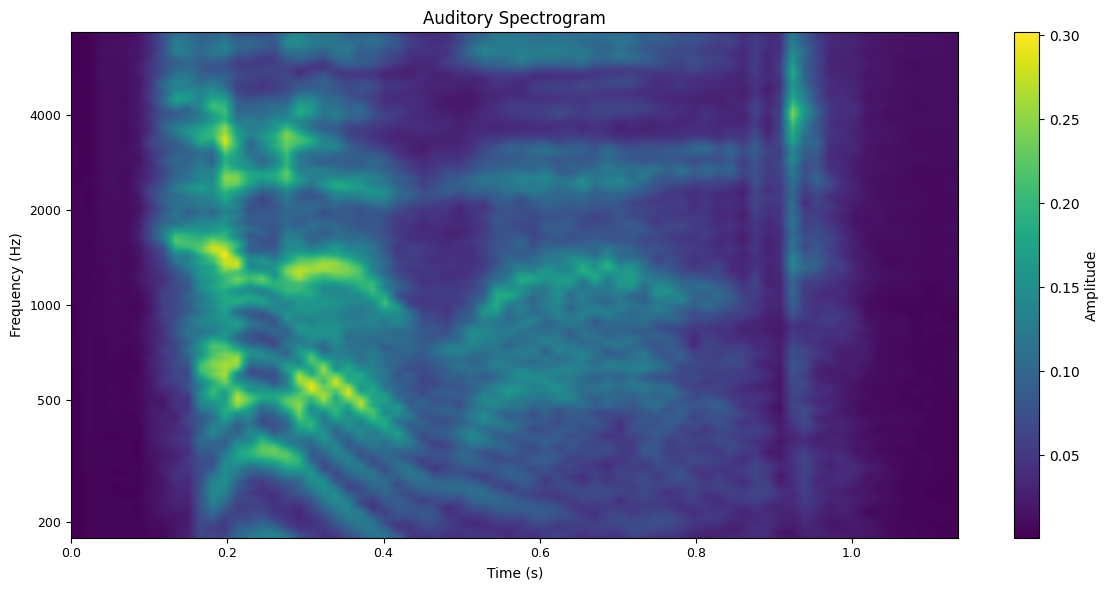

<Axes: title={'center': 'Auditory Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [4]:
# Plot spectrogram
stm.plot.plt_spectrogram(spectrogram, title="Auditory Spectrogram")

In [5]:
# Compute RSF representation
rsf = model.rsf(spectrogram)

print("\n=== RSF Stats ===")
print(f"Shape: {rsf.shape}")
print(f"  - n_frames: {rsf.n_frames}")
print(f"  - n_rates: {rsf.n_rates}")
print(f"  - n_scales: {rsf.n_scales}")
print(f"  - n_freqs: {rsf.n_freqs}")
print(f"Min: {rsf.data.min():.6f}")
print(f"Max: {rsf.data.max():.6f}")
print(f"Rates: {rsf.rates}")
print(f"Scales: {rsf.scales}")


=== RSF Stats ===
Shape: (42, 40, 24, 128)
  - n_frames: 42
  - n_rates: 40
  - n_scales: 24
  - n_freqs: 128
Min: 0.022306
Max: 13.110127
Rates: [-32.         -27.65510059 -23.90014339 -20.65502717 -17.85052668
 -15.42681597 -13.3321921  -11.5219723   -9.95754072  -8.60552469
  -7.43708284  -6.42728981  -5.55460457  -4.80041088  -4.14862018
  -3.58532838  -3.09851928  -2.6778082   -2.31422047  -2.
   2.           2.31422047   2.6778082    3.09851928   3.58532838
   4.14862018   4.80041088   5.55460457   6.42728981   7.43708284
   8.60552469   9.95754072  11.5219723   13.3321921   15.42681597
  17.85052668  20.65502717  23.90014339  27.65510059  32.        ]
Scales: [0.25       0.29065735 0.33792678 0.39288362 0.45677805 0.53106359
 0.61743014 0.71784244 0.83458473 0.97031275 1.12811414 1.31157867
 1.52487993 1.77287025 2.06119109 2.39640137 2.78612671 3.23923284
 3.76602735 4.37849415 5.09056605 5.91844179 6.88095446 8.        ]


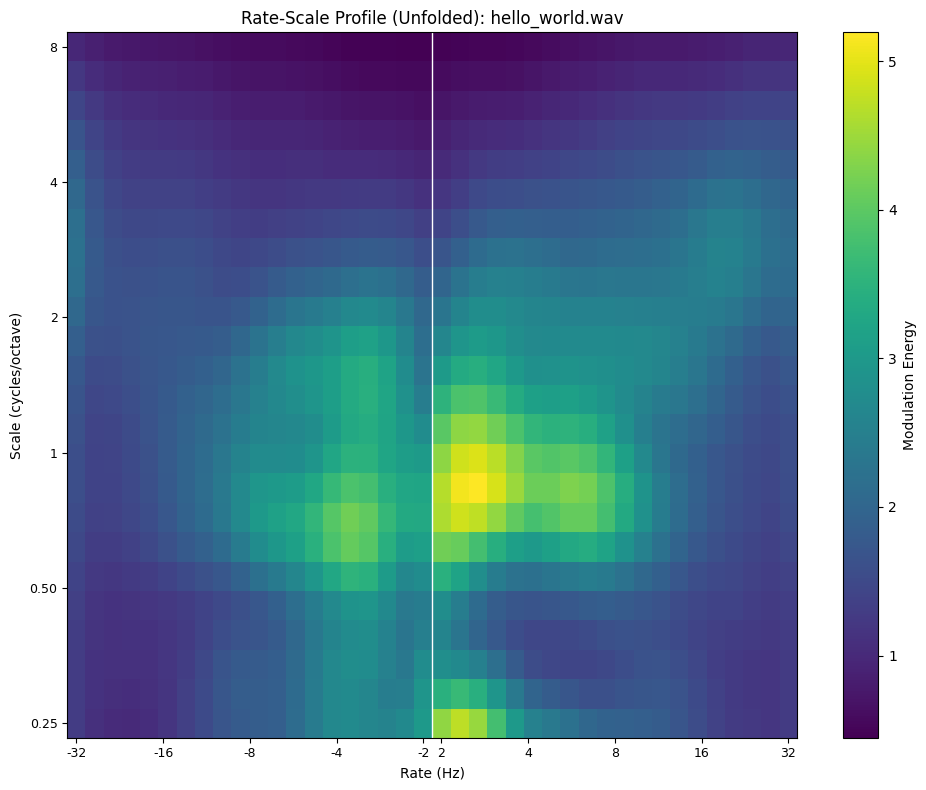

<Axes: title={'center': 'Rate-Scale Profile (Unfolded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [6]:
# Plot RSF - unfolded
stm.plot.plt_rsf(rsf, title=f"Rate-Scale Profile (Unfolded): {filepath.name}")

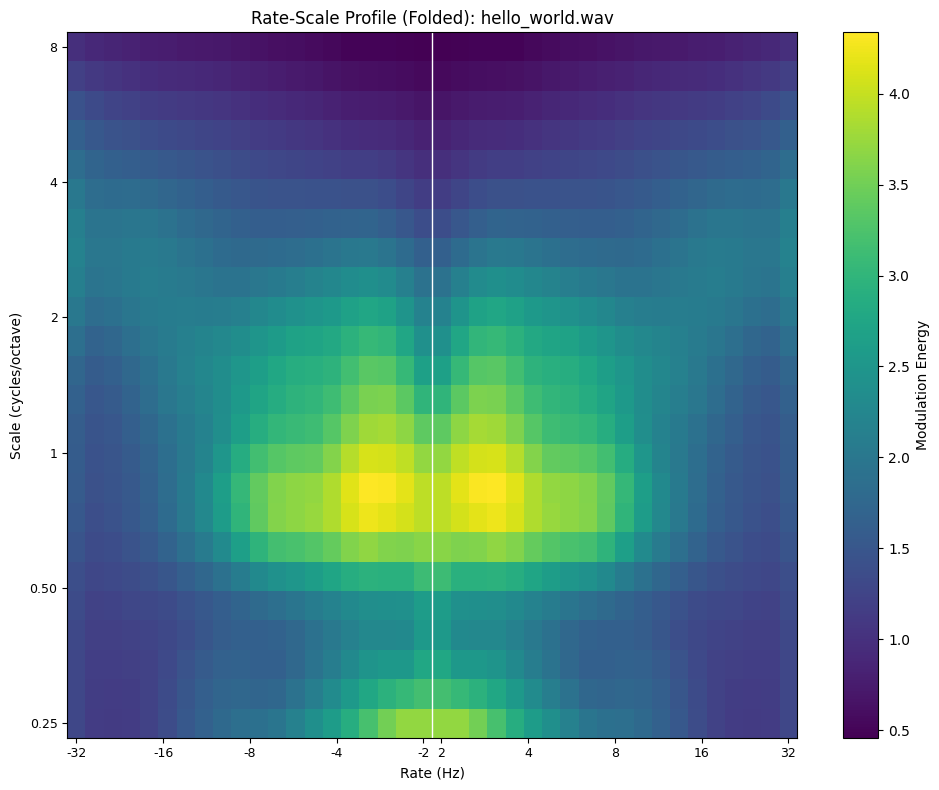

<Axes: title={'center': 'Rate-Scale Profile (Folded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [7]:
# Plot RSF - folded (symmetric)
stm.plot.plt_rsf(rsf, fold=True, title=f"Rate-Scale Profile (Folded): {filepath.name}")

In [8]:
# Access rate-scale matrix directly
rs_matrix = rsf.rate_scale_matrix(fold=False)
rs_folded = rsf.rate_scale_matrix(fold=True)
print(f"Rate-scale matrix shape: {rs_matrix.shape}")
print(f"Folded matrix shape: {rs_folded.shape}")

Rate-scale matrix shape: (24, 40)
Folded matrix shape: (24, 40)
